<a href="https://colab.research.google.com/github/holly0923p-stack/IntelligentData_TextAnalytics/blob/main/IDTA_imdb_item2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and loading data

import libaries

In [ ]:
import numpy as np
import pandas as pd
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

!pip install gensim
import gensim
from gensim.models import Word2Vec, KeyedVectors

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

import data

In [ ]:
reviews = pd.read_csv("imdb_labelled.txt", delimiter='\t', header=None, names=['text', 'sentiment'])

# **Data preprocessing**


### explore dataset

In [ ]:
reviews.head()

,text,sentiment
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [ ]:
reviews.shape

(748, 2)

In [ ]:
reviews['sentiment'].value_counts()

,count
sentiment,
1,386
0,362


In [ ]:
#text column datatype to string
reviews = reviews.astype({'text':'string'})

In [ ]:
text = reviews['text']
text[:5]

,text
0,"A very, very, very slow-moving, aimless movie ..."
1,Not sure who was more lost - the flat characte...
2,Attempting artiness with black & white and cle...
3,Very little music or anything to speak of.
4,The best scene in the movie was when Gerardo i...


### 1.removing punctuation  2.removing numbers  3.change text to lowercase

In [ ]:
text1 = []

for review in text:
  #print sentence & remove punctuation
  review = review.translate(str.maketrans('','', string.punctuation))
  #remove numbers
  review = review.translate(str.maketrans('','', string.digits))
  #make lowercase
  review = review.lower()
  #print
  text1.append(review)

text1[:5]

['a very very very slowmoving aimless movie about a distressed drifting young man  ',
 'not sure who was more lost  the flat characters or the audience nearly half of whom walked out  ',
 'attempting artiness with black  white and clever camera angles the movie disappointed  became even more ridiculous  as the acting was poor and the plot and lines almost nonexistent  ',
 'very little music or anything to speak of  ',
 'the best scene in the movie was when gerardo is trying to find a song that keeps running through his head  ']

### Remove stop words

In [ ]:
text1 = pd.Series(text1)
text[:5]

,text
0,"A very, very, very slow-moving, aimless movie ..."
1,Not sure who was more lost - the flat characte...
2,Attempting artiness with black & white and cle...
3,Very little music or anything to speak of.
4,The best scene in the movie was when Gerardo i...


In [ ]:
#setting english stopwords
stop_words = set(stopwords.words('english'))

text1 = text1.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))
text1[:5]

,0
0,slowmoving aimless movie distressed drifting y...
1,sure lost flat characters audience nearly half...
2,attempting artiness black white clever camera ...
3,little music anything speak
4,best scene movie gerardo trying find song keep...


### 5) lemmatising.

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
text2 = text1.apply(lambda x:' '.join(lemmatizer.lemmatize(w) for w in x.split()))
text2[:5] #not good

,0
0,slowmoving aimless movie distressed drifting y...
1,sure lost flat character audience nearly half ...
2,attempting artiness black white clever camera ...
3,little music anything speak
4,best scene movie gerardo trying find song keep...


In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

#lemmatising with POS tags

from nltk.corpus import wordnet
def get_wordnet_pos(word):
  #map pos tag to first character
  tag = nltk.pos_tag([word])[0][1][0].upper()
  tag_dict = {"J": wordnet.ADJ,
              "N": wordnet.NOUN,
              "V": wordnet.VERB,
              "R": wordnet.ADV}

  return tag_dict.get(tag, wordnet.NOUN)

#init the wordnet lemmatiser
lemmatizer = WordNetLemmatizer()
text3 = text1.apply(lambda x:' '.join(lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in x.split()))
text3[:5]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,0
0,slowmoving aimless movie distressed drift youn...
1,sure lose flat character audience nearly half ...
2,attempt artiness black white clever camera ang...
3,little music anything speak
4,best scene movie gerardo try find song keep ru...


In [ ]:
#stemming (remove endings)
ps = nltk.PorterStemmer()

text4 = text1.apply(lambda x:' '.join(ps.stem(term) for term in x.split()))
text4[:5]

,0
0,slowmov aimless movi distress drift young man
1,sure lost flat charact audienc nearli half walk
2,attempt arti black white clever camera angl mo...
3,littl music anyth speak
4,best scene movi gerardo tri find song keep run...


# **Classification**

### bag-ofwords/terms representation

In [ ]:
label = reviews['sentiment']
#put back together preprocessed text and the lable
reviews1 = list(zip(text3, label))


reviewsP = pd.DataFrame (reviews1, columns = ['Review', 'Sentiment'])
reviewsP


,Review,Sentiment
0,slowmoving aimless movie distressed drift youn...,0
1,sure lose flat character audience nearly half ...,0
2,attempt artiness black white clever camera ang...,0
3,little music anything speak,0
4,best scene movie gerardo try find song keep ru...,1
...,...,...
743,get bore watch jessice lange take clothes,0
744,unfortunately virtue film production work lose...,0
745,word embarrass,0
746,exceptionally bad,0


In [ ]:
#data shuffles so order does not effect classification
reviewsP1 = reviewsP.sample(frac=1, random_state=1).reset_index()
reviewsP1.head()

,index,Review,Sentiment
0,265,premise film ridiculous president u,0
1,519,find well movie youtube,0
2,584,saw child tv back stranger love,1
3,717,time seem film animation dominate disneypixars...,1
4,90,also real treat see anthony quinn play crazy h...,1


In [ ]:
#split dataset
from sklearn.model_selection import train_test_split

X = reviewsP1.Review
y = reviewsP1.Sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train dataset by splitting
train_reviews = X_train
train_sentiments = y_train

#test dataset
test_reviews = X_test
test_sentiments = y_test

print(train_reviews.shape, train_sentiments.shape)
print(test_reviews.shape, test_sentiments.shape)

(598,) (598,)
(150,) (150,)


In [ ]:
train_reviews[0]

'premise film ridiculous president u'

In [ ]:
#count vectoriser for bag of words
cv = CountVectorizer()

#transform train reviews
cv_train_reviews = cv.fit_transform(train_reviews)

#transform test reviews
cv_test_reviews = cv.transform(test_reviews)

print('BOW_cv_train:',cv_train_reviews.shape)
print('BOW_cv_test:', cv_test_reviews.shape)

BOW_cv_train: (598, 2367)
BOW_cv_test: (150, 2367)


In [ ]:
print(cv_train_reviews[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (1, 2367)>
  Coords	Values
  (0, 2190)	1
  (0, 449)	1
  (0, 879)	1
  (0, 695)	1
  (0, 982)	1
  (0, 2223)	1
  (0, 717)	1
  (0, 2321)	1
  (0, 782)	1
  (0, 854)	1


transform using tf-idf

In [ ]:
#tf-idf vectoriser
tv = TfidfVectorizer()

#transform train reviews
tv_train_reviews = tv.fit_transform(train_reviews)

#transform test reviews
tv_test_reviews = tv.transform(test_reviews)
print('Tfidf_train:',tv_train_reviews.shape)
print('Tfidf_test:', tv_test_reviews.shape)

Tfidf_train: (598, 2367)
Tfidf_test: (150, 2367)


In [ ]:
print(tv_train_reviews[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (1, 2367)>
  Coords	Values
  (0, 2190)	0.308683896092822
  (0, 449)	0.3234622797081858
  (0, 879)	0.27993613047489335
  (0, 695)	0.308683896092822
  (0, 982)	0.3234622797081858
  (0, 2223)	0.24813575161634727
  (0, 717)	0.34429124155206914
  (0, 2321)	0.3234622797081858
  (0, 782)	0.34429124155206914
  (0, 854)	0.34429124155206914


In [ ]:
print(train_sentiments)
print(test_sentiments)

593    0
131    0
44     0
70     1
670    1
      ..
71     0
106    1
270    0
435    1
102    0
Name: Sentiment, Length: 598, dtype: int64
580    0
356    1
133    0
250    1
299    0
      ..
627    0
90     1
642    1
683    1
69     1
Name: Sentiment, Length: 150, dtype: int64


### algorithm 1

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score, roc_curve

In [ ]:
#decision Tree

#training model
DT = DecisionTreeClassifier(criterion='entropy', random_state=0)

#fit model for BoW
DT_bow = DT.fit(cv_train_reviews, train_sentiments)

#fit model for tf-idf
DT_tfidf = DT.fit(tv_train_reviews, train_sentiments)

#predicting model for BoW
DT_bow_pred = DT_bow.predict(cv_test_reviews)

#predicting model for tf-idf
DT_tfidf_pred = DT_tfidf.predict(tv_test_reviews)



### Decision Tree Model Metrics (Bag-of-Words)

In [ ]:
print('--- Decision Tree (Bag-of-Words) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, DT_bow_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, DT_bow_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, DT_bow_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, DT_bow_pred):.4f}')

--- Decision Tree (Bag-of-Words) Metrics ---
Confusion Matrix:
[[36 33]
 [11 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.52      0.62        69
           1       0.68      0.86      0.76        81

    accuracy                           0.71       150
   macro avg       0.72      0.69      0.69       150
weighted avg       0.72      0.71      0.70       150

Accuracy: 0.7067
AUC: 0.6930


### Decision Tree Model Metrics (TF-IDF)

In [ ]:
print('--- Decision Tree (TF-IDF) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, DT_tfidf_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, DT_tfidf_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, DT_tfidf_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, DT_tfidf_pred):.4f}')

--- Decision Tree (TF-IDF) Metrics ---
Confusion Matrix:
[[46 23]
 [21 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68        69
           1       0.72      0.74      0.73        81

    accuracy                           0.71       150
   macro avg       0.70      0.70      0.70       150
weighted avg       0.71      0.71      0.71       150

Accuracy: 0.7067
AUC: 0.7037


roc_auc_score for DT:  0.7037037037037037


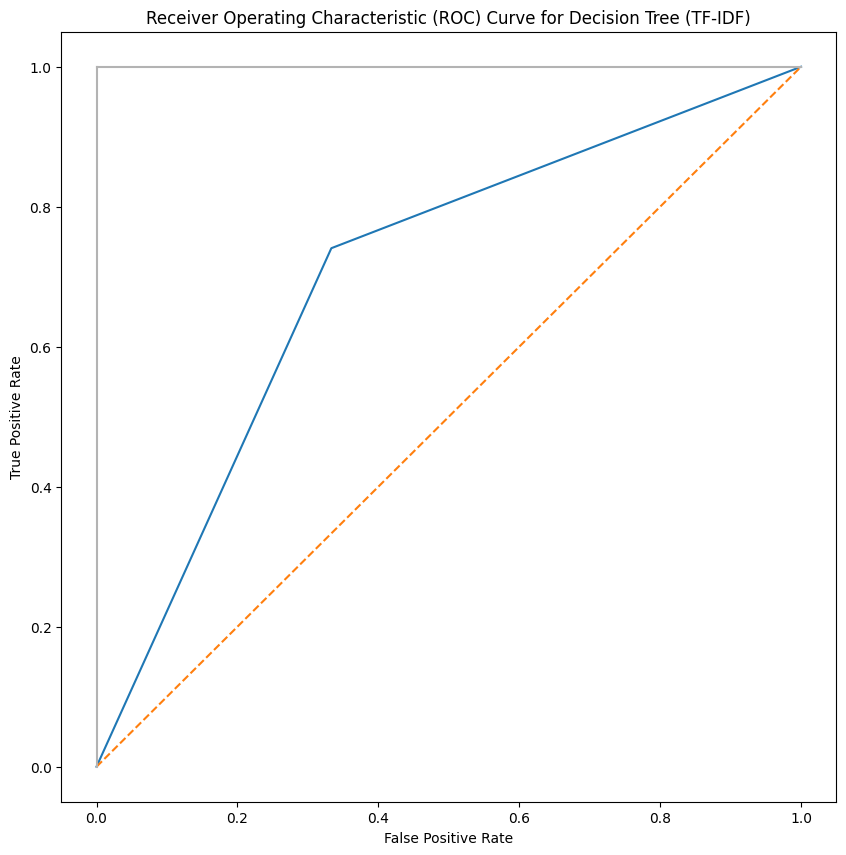

In [ ]:
#AUC score and ROC curve
from sklearn.metrics import roc_auc_score, roc_curve

FP, TP, thresholds = roc_curve(test_sentiments, DT_tfidf_pred)
print('roc_auc_score for DT: ', roc_auc_score(test_sentiments, DT_tfidf_pred))

import matplotlib.pyplot as plt

plt.subplots(1, figsize=(10,10))
plt.plot(FP, TP)
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree (TF-IDF)')
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

### algorithm 2

In [ ]:
from sklearn.naive_bayes import MultinomialNB

#training model
NB = MultinomialNB()

#fit model for BoW
NB_bow = NB.fit(cv_train_reviews, train_sentiments)

#fit model for tf-idf
NB_tfidf = NB.fit(tv_train_reviews, train_sentiments)

#predicting model for BoW
NB_bow_pred = NB_bow.predict(cv_test_reviews)

#predicting model for tf-idf
NB_tfidf_pred = NB_tfidf.predict(tv_test_reviews)

### Naive Bayes Model Metrics (Bag-of-Words)

In [ ]:
print('--- Naive Bayes (Bag-of-Words) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, NB_bow_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, NB_bow_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, NB_bow_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, NB_bow_pred):.4f}')

--- Naive Bayes (Bag-of-Words) Metrics ---
Confusion Matrix:
[[55 14]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        69
           1       0.82      0.77      0.79        81

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150

Accuracy: 0.7800
AUC: 0.7813


### Naive Bayes Model Metrics (TF-IDF)

In [ ]:
print('--- Naive Bayes (TF-IDF) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, NB_tfidf_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, NB_tfidf_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, NB_tfidf_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, NB_tfidf_pred):.4f}')

--- Naive Bayes (TF-IDF) Metrics ---
Confusion Matrix:
[[57 12]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        69
           1       0.84      0.79      0.82        81

    accuracy                           0.81       150
   macro avg       0.81      0.81      0.81       150
weighted avg       0.81      0.81      0.81       150

Accuracy: 0.8067
AUC: 0.8081


roc_auc_score for Naive Bayes:  0.8081052066559312


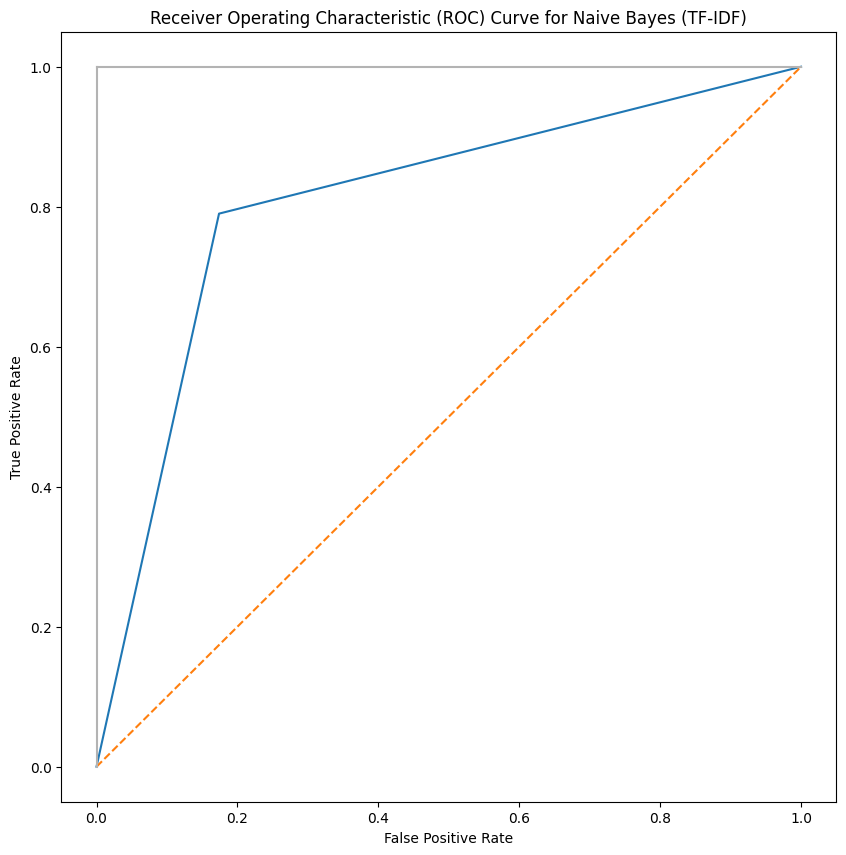

In [ ]:
FP_nb, TP_nb, thresholds_nb = roc_curve(test_sentiments, NB_tfidf_pred)
print('roc_auc_score for Naive Bayes: ', roc_auc_score(test_sentiments, NB_tfidf_pred))


plt.subplots(1, figsize=(10,10))
plt.plot(FP_nb, TP_nb)
plt.title('Receiver Operating Characteristic (ROC) Curve for Naive Bayes (TF-IDF)')
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

### algorithm 3

In [ ]:
from sklearn.svm import SVC

#training model
SVM = SVC(kernel='linear', random_state=0)

#fit model for BoW
SVM_bow = SVM.fit(cv_train_reviews, train_sentiments)

#fit model for tf-idf
SVM_tfidf = SVM.fit(tv_train_reviews, train_sentiments)

#predicting model for BoW
SVM_bow_pred = SVM_bow.predict(cv_test_reviews)

#predicting model for tf-idf
SVM_tfidf_pred = SVM_tfidf.predict(tv_test_reviews)

### SVM Model Metrics (Bag-of-Words)

In [ ]:
print('--- SVM (Bag-of-Words) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, SVM_bow_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, SVM_bow_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, SVM_bow_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, SVM_bow_pred):.4f}')

--- SVM (Bag-of-Words) Metrics ---
Confusion Matrix:
[[57 12]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        69
           1       0.85      0.81      0.83        81

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150

Accuracy: 0.8200
AUC: 0.8205


### SVM Model Metrics (TF-IDF)

In [ ]:
print('--- SVM (TF-IDF) Metrics ---')
print('Confusion Matrix:')
print(confusion_matrix(test_sentiments, SVM_tfidf_pred))
print('\nClassification Report:')
print(classification_report(test_sentiments, SVM_tfidf_pred))
print(f'Accuracy: {accuracy_score(test_sentiments, SVM_tfidf_pred):.4f}')
print(f'AUC: {roc_auc_score(test_sentiments, SVM_tfidf_pred):.4f}')

--- SVM (TF-IDF) Metrics ---
Confusion Matrix:
[[58 11]
 [16 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        69
           1       0.86      0.80      0.83        81

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150

Accuracy: 0.8200
AUC: 0.8215


roc_auc_score for SVM:  0.8215244229736983


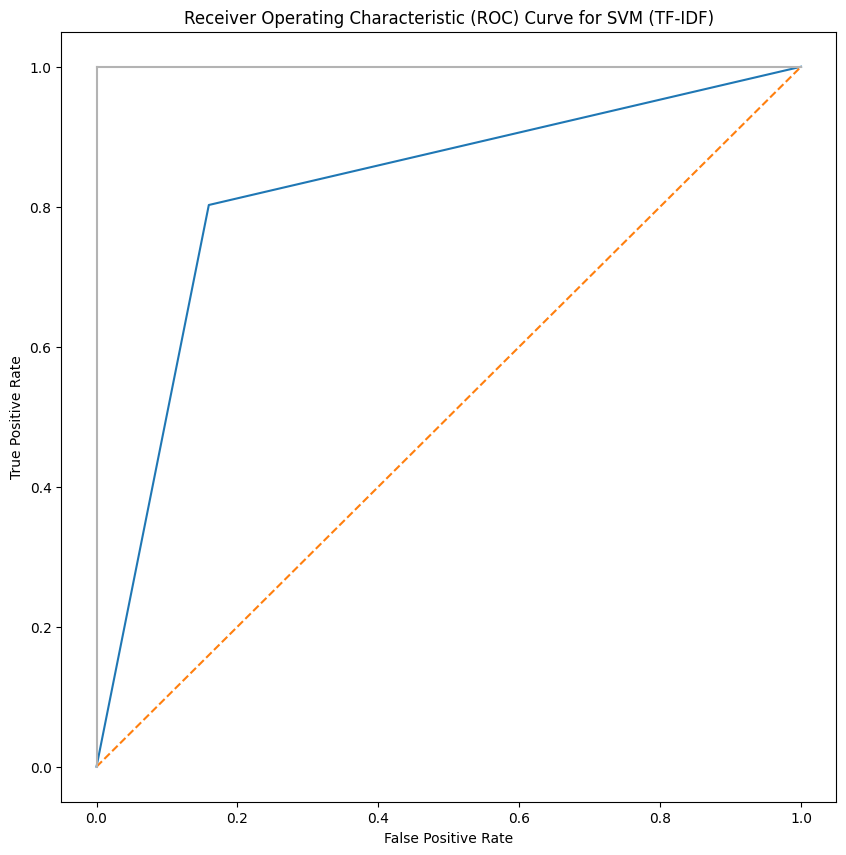

In [ ]:
FP_svm, TP_svm, thresholds_svm = roc_curve(test_sentiments, SVM_tfidf_pred)
print('roc_auc_score for SVM: ', roc_auc_score(test_sentiments, SVM_tfidf_pred))


plt.subplots(1, figsize=(10,10))
plt.plot(FP_svm, TP_svm)
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM (TF-IDF)')
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# **BERT-based model with fine-tuning**

In [ ]:
!pip install tf-models-official

In [ ]:
import shutil
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization  # to create AdamW optimizer
import matplotlib.pyplot as plt

In [ ]:
reviews['sentiment'].value_counts()

,count
sentiment,
1,386
0,362


In [ ]:
reviews1 = list(zip(reviews['text'], label))

reviews1 = pd.DataFrame (reviews1, columns = ['review', 'sentiment'])
reviews1

,review,sentiment
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
...,...,...
743,I just got bored watching Jessice Lange take h...,0
744,"Unfortunately, any virtue in this film's produ...",0
745,"In a word, it is embarrassing.",0
746,Exceptionally bad!,0


In [ ]:
reviews1 = reviews1.sample(frac=1, random_state=1)
reviews1.reset_index(drop=True, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

#split and take the test set
X, X_test, y, y_test = (train_test_split(reviews1['review'], reviews1['sentiment'],
                                                     stratify=reviews1['sentiment'],
                                                     test_size=0.2,
                                                     train_size=0.8
                                                     ))

In [ ]:
#split the train set (X) into train and validation
X_train, X_val, y_train, y_val = (train_test_split(X, y,
                                                     stratify=y,
                                                     test_size=0.25,
                                                     train_size=0.75
                                                     ))


In [ ]:
#@title Choose a BERT model to fine-tune

#the model has 5 layers (L), 512 hidden size H and 8 attention heads
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'

map_name_to_handle = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
}

map_model_to_preprocess = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [ ]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

In [ ]:
reviews1['review'][0]

'But the premise of the film was so ridiculous: that the President of the U.S.  '

In [ ]:
text_test = ['But the premise of the film was so ridiculous: that the President of the U.S. ']
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

Keys       : ['input_type_ids', 'input_mask', 'input_word_ids']
Shape      : (1, 128)
Word Ids   : [  101  2021  1996 18458  1997  1996  2143  2001  2061  9951  1024  2008]
Input Mask : [1 1 1 1 1 1 1 1 1 1 1 1]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
bert_model = hub.KerasLayer(tfhub_handle_encoder)

In [ ]:
bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Pooled Outputs Shape:(1, 512)
Pooled Outputs Values:[-0.25066411 -0.09412076 -0.30226642  0.08652018 -0.5710845   0.79781073
  0.9965778  -0.9300558  -0.1050768  -0.8885106  -0.04133753 -0.9887515 ]
Sequence Outputs Shape:(1, 128, 512)
Sequence Outputs Values:[[ 0.65730464  0.01586002  0.4268625  ... -0.2801381  -0.02437693
  -0.585219  ]
 [-1.0859427   0.70992476 -1.5207543  ... -0.63638914 -0.38143724
   0.23959363]
 [-0.5712918   0.64068705 -1.4037994  ... -0.246665   -0.1383933
   0.42763588]
 ...
 [-0.48578542  0.12233339 -1.2606215  ...  0.02771379 -1.3281798
  -0.01565013]
 [ 1.2906352  -0.35436365  0.17404822 ...  0.33582312 -0.45301312
  -0.05232605]
 [-0.08729113 -0.5875064  -0.4096029  ... -0.5237823  -0.5476143
  -0.61795735]]


In [ ]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
  encoder_inputs = preprocessing_layer(text_input)
  encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
  outputs = encoder(encoder_inputs)
  net = outputs['pooled_output']
  net = tf.keras.layers.Dropout(0.2)(net)
  net = tf.keras.layers.Dense(
      1,
      activation=None,
      kernel_regularizer=tf.keras.regularizers.l2(1e-4),
      name='classifier'
  )(net)
  return tf.keras.Model(text_input, net)

In [ ]:
 classifier_model = build_classifier_model()

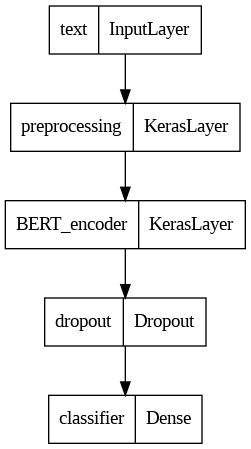

In [ ]:
tf.keras.utils.plot_model(classifier_model)

In [ ]:
epochs = 50
BATCH_SIZE = 32 # Define the batch size
steps_per_epoch = len(X_train) // BATCH_SIZE # Calculate steps per epoch based on training data size and batch size
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps) #10% of num_train_steps

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')

In [ ]:
#fine-tune BERT for classification
classifier_model.compile(optimizer,
                     loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc"),
                              tf.keras.metrics.AUC(from_logits=True, name="auc")

])
classifier_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

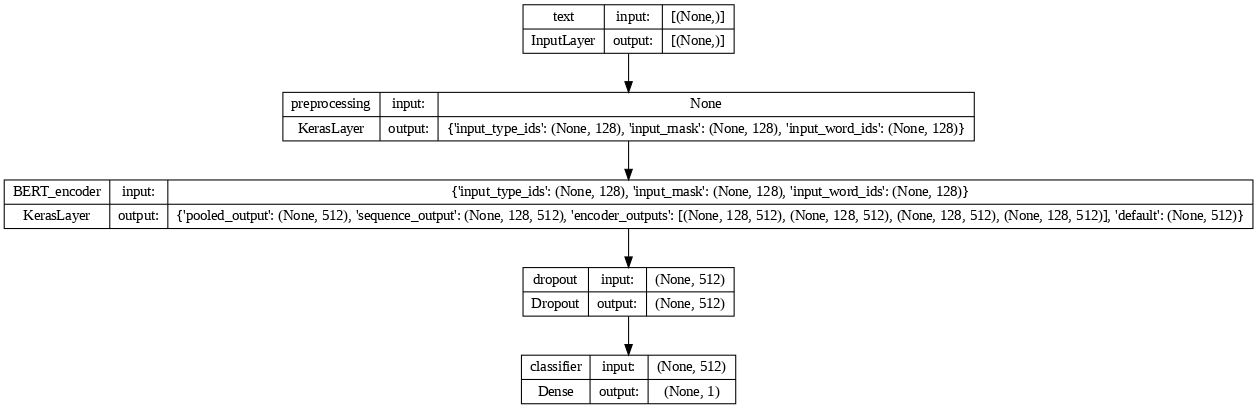

In [ ]:
tf.keras.utils.plot_model(model=classifier_model,show_shapes=True,dpi=76)

In [ ]:
print(f'Training model with {tfhub_handle_encoder}')

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    )
]

history = classifier_model.fit(X_train,
                               y_train,
                               validation_data=(X_val, y_val),
                               epochs=epochs, callbacks=callbacks)

Training model with https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Epoch 1/50
14/14 [==============================] - 15s 272ms/step - loss: 0.8818 - acc: 0.4978 - auc: 0.4999 - val_loss: 0.7690 - val_acc: 0.4800 - val_auc: 0.4893
Epoch 2/50
14/14 [==============================] - 3s 208ms/step - loss: 0.7385 - acc: 0.4911 - auc: 0.5248 - val_loss: 0.6640 - val_acc: 0.5200 - val_auc: 0.6748
Epoch 3/50
14/14 [==============================] - 3s 228ms/step - loss: 0.6312 - acc: 0.6339 - auc: 0.6947 - val_loss: 0.5699 - val_acc: 0.6800 - val_auc: 0.7950
Epoch 4/50
14/14 [==============================] - 3s 211ms/step - loss: 0.5242 - acc: 0.7366 - auc: 0.8262 - val_loss: 0.4852 - val_acc: 0.7533 - val_auc: 0.8599
Epoch 5/50
14/14 [==============================] - 3s 212ms/step - loss: 0.3931 - acc: 0.8192 - auc: 0.9152 - val_loss: 0.4061 - val_acc: 0.8133 - val_auc: 0.9022
Epoch 6/50
14/14 [==============================] - 3s 209ms/step - loss: 0.2471 - acc:

dict_keys(['loss', 'acc', 'auc', 'val_loss', 'val_acc', 'val_auc'])


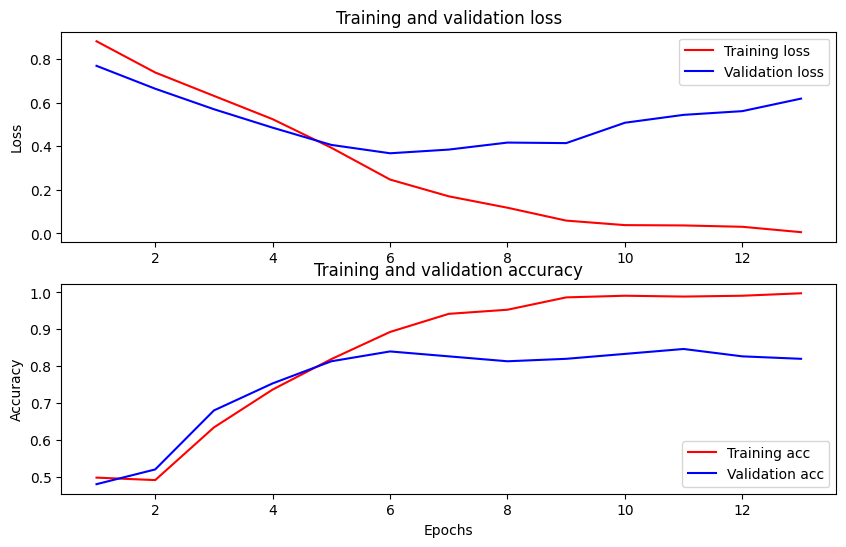

In [ ]:
history_dict = history.history
print(history_dict.keys())

acc = history_dict['acc']
val_acc = history_dict['val_acc']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [ ]:
loss, accuracy, auc = classifier_model.evaluate(X_test, y_test)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')
print(f'AUC: {auc}')

5/5 [==============================] - 0s 66ms/step - loss: 0.3234 - acc: 0.8933 - auc: 0.9388
Loss: 0.32337263226509094
Accuracy: 0.8933333158493042
AUC: 0.9388008713722229


In [ ]:
#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#predicted values using the model
y_pred=classifier_model.predict(X_test)

print(y_pred.flatten())

5/5 [==============================] - 1s 66ms/step
[ 0.6980238  -5.2813277   5.006341   -5.991221    3.108385   -6.4362874
  2.1603127   3.6648674   5.6439166   5.3128986  -0.96402085 -5.505937
 -2.9758618   3.0015073  -0.8486484  -3.721221   -4.6782866   5.189627
 -0.21164978 -2.8727155  -3.6778777   1.3289448  -6.07345    -3.891256
  2.9673884   6.2568607   5.384536    2.71496    -5.0856323   2.8454695
 -2.856702    5.183479   -5.1992574   4.4436455  -4.3637667  -3.3174193
  5.0204954   4.652938    1.6189337  -4.9288816  -4.1831822  -1.8659968
  5.880379    1.6787723  -2.6580954  -2.8695028  -5.8110437   5.063122
  4.0229206   4.6179457   3.2219067   5.758972   -3.4090364  -5.3584447
  3.4180157  -4.785146   -5.424654   -2.5642474  -4.321505    2.350411
 -2.4356616  -3.6964529   5.2420564  -4.765863    0.1978458   5.538758
 -5.455575    2.8946137  -0.54375386  4.4180484  -2.2843976   3.5439699
  6.003749    4.1547565   5.834163    2.1190174   5.7384405  -2.5706003
  6.015695   -3.54

In [ ]:
#len(y_pred)

for i in range(len(y_pred)):
  if y_pred[i]<0.5:
    y_pred[i] = 0
  else: y_pred[i] = 1

print(y_pred.flatten())

[1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 1. 0. 0.]


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[70  3]
 [13 64]] 

              precision    recall  f1-score   support

           0       0.84      0.96      0.90        73
           1       0.96      0.83      0.89        77

    accuracy                           0.89       150
   macro avg       0.90      0.90      0.89       150
weighted avg       0.90      0.89      0.89       150

Accuracy: 0.8933333333333333
AUC: 0.8950364703789362


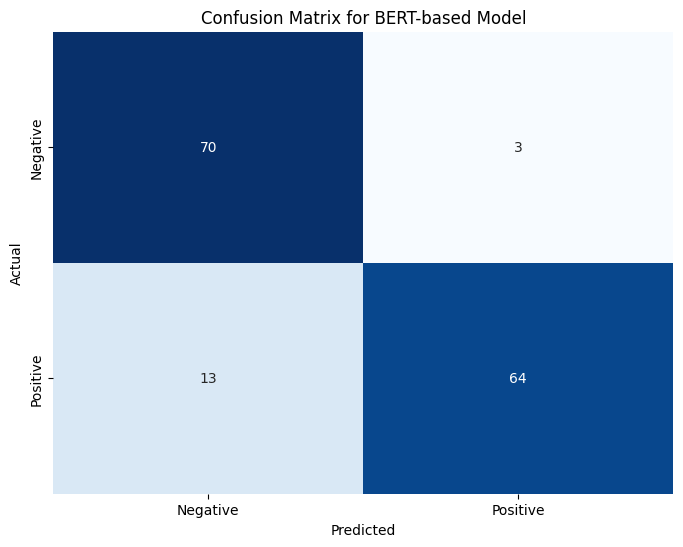

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the BERT model
cm_bert = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for BERT-based Model')
plt.show()

#  **Topic detection**

In [ ]:
text1 = pd.Series(text1)

In [ ]:
#remove stop words

#Setting English stopwords
stop_words = set(stopwords.words('english'))

text1 = text1.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))

In [ ]:
#apply stemming
ps = nltk.PorterStemmer()

text1 = text1.apply(lambda x: ' '.join(ps.stem(term) for term in x.split()))
text1[:5]

,0
0,slowmov aimless movi distress drift young man
1,sure lost flat charact audienc nearli half walk
2,attempt arti black white clever camera angl mo...
3,littl music anyth speak
4,best scene movi gerardo tri find song keep run...


In [ ]:
reviews1 = list(zip(text1, label))

In [ ]:
reviewsP = pd.DataFrame (reviews1, columns = ['Review', 'Sentiment'])
reviewsP

,Review,Sentiment
0,slowmov aimless movi distress drift young man,0
1,sure lost flat charact audienc nearli half walk,0
2,attempt arti black white clever camera angl mo...,0
3,littl music anyth speak,0
4,best scene movi gerardo tri find song keep run...,1
...,...,...
743,got bore watch jessic lang take cloth,0
744,unfortun virtu film product work lost regrett ...,0
745,word embarrass,0
746,except bad,0


In [ ]:
data = reviewsP.Review.values.tolist()

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence)))

words = list(sent_to_words(data))

In [ ]:
import gensim.corpora as corpora

# Create Dictionary
id2word = corpora.Dictionary(words)

# Create Corpus
texts = words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]


In [ ]:
from pprint import pprint

# number of topics
num_topics = 10

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)

# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
#doc_lda = lda_model[corpus]

[(0,
  '0.023*"movi" + 0.013*"good" + 0.012*"make" + 0.011*"film" + 0.010*"charact" '
  '+ 0.010*"like" + 0.008*"look" + 0.008*"actor" + 0.008*"time" + '
  '0.007*"scene"'),
 (1,
  '0.022*"movi" + 0.020*"bad" + 0.012*"love" + 0.011*"one" + 0.011*"film" + '
  '0.010*"act" + 0.007*"watch" + 0.006*"charact" + 0.005*"even" + 0.004*"go"'),
 (2,
  '0.021*"film" + 0.017*"movi" + 0.008*"act" + 0.008*"great" + 0.008*"good" + '
  '0.007*"stori" + 0.006*"like" + 0.005*"year" + 0.005*"look" + 0.005*"bad"'),
 (3,
  '0.035*"movi" + 0.023*"film" + 0.011*"one" + 0.008*"work" + 0.007*"watch" + '
  '0.007*"better" + 0.007*"didnt" + 0.006*"realli" + 0.005*"great" + '
  '0.005*"bore"'),
 (4,
  '0.028*"film" + 0.010*"see" + 0.009*"realli" + 0.008*"would" + 0.007*"movi" '
  '+ 0.007*"bad" + 0.006*"year" + 0.006*"time" + 0.006*"one" + 0.006*"great"'),
 (5,
  '0.020*"movi" + 0.019*"film" + 0.015*"one" + 0.011*"realli" + 0.008*"love" + '
  '0.007*"like" + 0.007*"aw" + 0.006*"bad" + 0.006*"funni" + 0.005*"enjoy

In [ ]:
pip install pyldavis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 50.2 MB/s eta 0:00:00


In [ ]:
import pyLDAvis.gensim_models
import pyLDAvis
import joblib

# Visualize the topics
pyLDAvis.enable_notebook()

# Use 'threading' backend for joblib to avoid pickling issues across processes.
# 'threading' backend shares memory, so objects don't need to be serialized/deserialized.
with joblib.parallel_backend('threading'):
    LDAvis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word, n_jobs=1)

LDAvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.086769  0.021922       1        1  19.115764
3      0.022835  0.049269       2        1  15.477914
7      0.003349  0.039010       3        1  13.487376
2     -0.000193 -0.010450       4        1   9.591492
6      0.020909  0.011429       5        1   8.272755
8     -0.012378 -0.114271       6        1   7.613698
4     -0.122276  0.034175       7        1   7.346823
5     -0.035383  0.002852       8        1   6.562393
1      0.027120 -0.012297       9        1   6.441514
9      0.009248 -0.021641      10        1   6.090270, topic_info=       Term        Freq       Total Category  logprob  loglift
451     bad   47.000000   47.000000  Default  30.0000  30.0000
97     film  139.000000  139.000000  Default  29.0000  29.0000
68     love   25.000000   25.000000  Default  28.0000  28.0000
4      movi  161.000000  161.000000  Default  27.0000  27.0000
76     look   24.000000   24.000000  Default  26.0000  26.0000
..      ...         ...         ...      ...      ...      ...
218   funni    1.431077   13.751672  Topic10  -5.7591   0.5357
334  screen    1.376080    9.893579  Topic10  -5.7983   0.8258
305    play    1.395157   22.518874  Topic10  -5.7845   0.0171
396   write    1.342745   12.248271  Topic10  -5.8228   0.5878
269    make    1.381414   29.529132  Topic10  -5.7944  -0.2638

[763 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
2026      4  0.682422  aailiyah
1870      6  0.729105   academi
15        1  0.174776       act
15        2  0.145647       act
15        3  0.058259       act
...     ...       ...       ...
402       3  0.133232      year
402       4  0.266464      year
402       7  0.199848      year
402       8  0.066616      year
1416      2  0.628905       yun

[1511 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 8, 3, 7, 9, 5, 6, 2, 10])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
